In [17]:
# Data: https://github.com/atilsamancioglu/DeepLearningBootcamp/blob/main/06-study_hours_grades.csv

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

In [19]:
df = pd.read_csv("06-study_hours_grades.csv")
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [20]:
X = torch.tensor(df["study_hours"].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df["grade"].values, dtype=torch.float32).unsqueeze(1)

# bunu yapıyoruz çünkü nn.Linear kullanacağız ve bu katman, ağırlıklarında diğer veri tipleri yerine float32 bekler
# ayrıca nn.Linear kullanırken 2 boyutlu girişler bekler: (batch_size, in_features)
# eğer unsqueeze yapmazsak, bu boyut eksik olur
# unsqueeze yapmadan çalıştır ve training loop'ta ne olduğuna bak?

In [21]:
print(X)
print(X.shape)
print(X.dtype)
print(X.ndim)

tensor([[3.7454],
        [9.5071],
        [7.3199],
        [5.9866],
        [1.5602],
        [1.5599],
        [0.5808],
        [8.6618],
        [6.0111],
        [7.0807],
        [0.2058],
        [9.6991],
        [8.3244],
        [2.1234],
        [1.8182],
        [1.8340],
        [3.0424],
        [5.2476],
        [4.3195],
        [2.9123],
        [6.1185],
        [1.3949],
        [2.9214],
        [3.6636],
        [4.5607],
        [7.8518],
        [1.9967],
        [5.1423],
        [5.9241],
        [0.4645],
        [6.0754],
        [1.7052],
        [0.6505],
        [9.4889],
        [9.6563],
        [8.0840],
        [3.0461],
        [0.9767],
        [6.8423],
        [4.4015],
        [1.2204],
        [4.9518],
        [0.3439],
        [9.0932],
        [2.5878],
        [6.6252],
        [3.1171],
        [5.2007],
        [5.4671],
        [1.8485]])
torch.Size([50, 1])
torch.float32
2


In [22]:
# train test split
train_split = int(len(X) * 0.8)

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [23]:
len(X_train), len(X_test)

(40, 10)

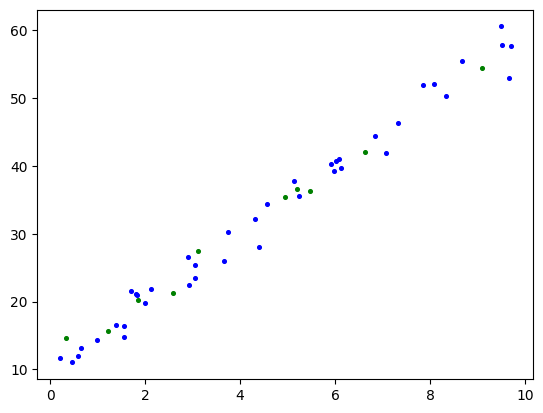

In [24]:
plt.scatter(X_train, y_train, c="b", s=7, label="Training data")
plt.scatter(X_test, y_test, c="g", s=7, label="Testing data")
plt.show()

In [25]:
import torch.nn as nn

In [26]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features = 1, out_features = 1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# ilerleyen bölümlerde modelleri nasıl çok katmanlı hale getireceğimizi, aktivasyon fonksiyonları eklemeyi vb. öğreneceğiz
# şu an nn.Linear kullanarak çok basit bir regresyon modeli kuruyoruz. gerçek hayatta böyle bir veriyle karşılaşsam sklearn kullanır ve bunu klasik makine öğrenmesiyle çözerdim
# ancak burada yapay sinir ağlarını (ANN) en basit haliyle pratik etmeye devam ediyoruz

## 🔍 Modeli Genişletmek: Çok Katmanlı Yapıya Geçiş

Basit modelimizde yalnızca tek bir `nn.Linear` katmanı kullanarak doğrusal bir regresyon gerçekleştirmiştik. Bu yaklaşım bazı problemler için yeterli olsa da, gerçek dünyadaki veriler genellikle daha karmaşık ilişkiler içerir.

Bu yüzden modeli aşağıdaki gibi genişleterek **çok katmanlı (deep) bir yapı** kurabiliriz:

```python
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer1 = nn.Linear(in_features=1, out_features=10)
    self.linear_layer2 = nn.Linear(in_features=10, out_features=10)
    self.linear_layer3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer3(
        self.linear_layer2(
            self.linear_layer1(x)
        )
    )
```

---

## 🧠 Katmanların Rolü

Bu model aslında basit bir **Multi-Layer Perceptron (MLP)** örneğidir:

* **1. Katman (`1 → 10`)**
  Giriş verisini daha geniş bir temsil uzayına taşır (feature expansion).

* **2. Katman (`10 → 10`)**
  Ara katman (hidden layer) olarak daha karmaşık örüntüleri öğrenmeye yardımcı olur.

* **3. Katman (`10 → 1`)**
  Öğrenilen temsili tekrar tek bir çıktıya indirger.

---

## ⚠️ Kritik Bir Nokta: Aktivasyon Fonksiyonları

Bu modelde dikkat edilmesi gereken önemli bir detay var:

> Katmanlar arasında **aktivasyon fonksiyonu yok**.

Bu ne anlama geliyor?

* Birden fazla katman olsa bile model hâlâ **doğrusal (linear)** davranır.
* Yani aslında tek katmanlı bir modele matematiksel olarak indirgenebilir.

👉 Gerçek anlamda güçlü bir model için katmanlar arasına örneğin:

```python
import torch.nn.functional as F

def forward(self, x):
    x = F.relu(self.linear_layer1(x))
    x = F.relu(self.linear_layer2(x))
    return self.linear_layer3(x)
```

şeklinde **ReLU gibi aktivasyon fonksiyonları** eklenmelidir.

---

## 🚀 Özet

* Tek katmanlı model → basit doğrusal ilişki öğrenir
* Çok katmanlı model → daha fazla temsil gücü sağlar
* Aktivasyon yoksa → hâlâ linear model
* Aktivasyon eklenirse → **non-linear (karmaşık) ilişkiler öğrenilebilir**

Bu adım, derin öğrenmeye geçişte en kritik yapı taşlarından biridir.


In [27]:
torch.manual_seed(42)
model = LinearRegressionModel()
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [28]:
model.state_dict()
# Modelin öğrenilebilir tüm parametrelerini (ağırlıklar ve bias'lar) bir sözlük (OrderedDict) olarak döndürür.
# Burada:
# - 'linear_layer.weight' → katmanın öğrendiği ağırlık değeri
# - 'linear_layer.bias'   → katmanın öğrendiği bias (sabit) değeri
# Bu değerler eğitim sırasında güncellenir ve modelin öğrendiği bilgiyi temsil eder.
# nn.Linear() Layer bizim için rastgele bir ağırlık ve sapma parametresi oluşturdu.

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [29]:
# Loss Function
loss_fn = nn.MSELoss() # -> MSE

# Optimizer
optimizer = torch.optim.SGD(params = model.parameters(), lr=0.001)

In [30]:
epochs = 120

for epoch in range(epochs):

  model.train()

  # 1. Forward pass
  y_pred = model(X_train)

  # 2. loss calculation
  loss = loss_fn(y_pred, y_train)

  # 3. reset optimizer
  optimizer.zero_grad()

  # 4. backward prop
  loss.backward()

  # 5. optimize the weights
  optimizer.step()

  # Test steps
  model.eval()
  with torch.inference_mode():
    test_pred = model(X_test)
    test_loss = loss_fn(test_pred, y_test)

    if epoch % 5 == 0:
      print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Loss: 965.6339721679688 | Test loss: 717.683349609375
Epoch: 5 | Loss: 530.086669921875 | Test loss: 405.685546875
Epoch: 10 | Loss: 295.7361755371094 | Test loss: 236.03225708007812
Epoch: 15 | Loss: 169.61843872070312 | Test loss: 143.42544555664062
Epoch: 20 | Loss: 101.72415924072266 | Test loss: 92.61088562011719
Epoch: 25 | Loss: 65.15110778808594 | Test loss: 64.53107452392578
Epoch: 30 | Loss: 45.427330017089844 | Test loss: 48.86598587036133
Epoch: 35 | Loss: 34.767799377441406 | Test loss: 40.014488220214844
Epoch: 40 | Loss: 28.984628677368164 | Test loss: 34.92718505859375
Epoch: 45 | Loss: 25.824926376342773 | Test loss: 31.93711280822754
Epoch: 50 | Loss: 24.0767879486084 | Test loss: 30.128173828125
Epoch: 55 | Loss: 23.088253021240234 | Test loss: 28.993366241455078
Epoch: 60 | Loss: 22.508625030517578 | Test loss: 28.2496337890625
Epoch: 65 | Loss: 22.149234771728516 | Test loss: 27.737096786499023
Epoch: 70 | Loss: 21.908586502075195 | Test loss: 27.3642539

In [32]:
print(model.state_dict())

OrderedDict({'linear_layer.weight': tensor([[6.2079]]), 'linear_layer.bias': tensor([2.2388])})


In [34]:
# bir tahminde bulunalım
with torch.inference_mode():
  y_preds = model(X_test)

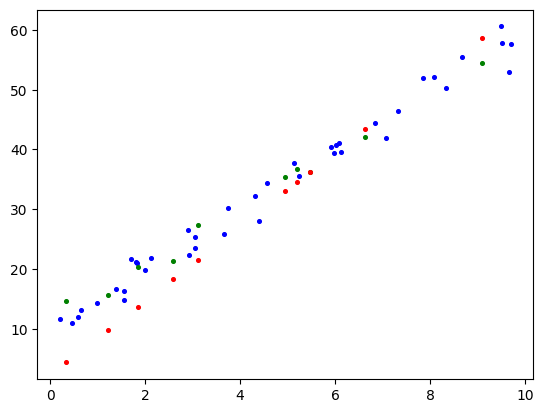

In [36]:
plt.scatter(X_train, y_train, c="b", s=7, label="Training data")
plt.scatter(X_test, y_test, c="g", s=7, label="Testing data")
plt.scatter(X_test, y_preds, c="r", s=7, label="Predictions")
plt.show()